In [6]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from src import utils
from src import mobi

### data

In [7]:
def get_tomtom_stat_sig_test(tomtom_summary_dir, nbp_list, rank_list, tool, top, standard):
    
    tfs = set(pd.read_csv("%s/%s_%s_%d_count_%s.txt" % (tomtom_summary_dir, tool, rank_list[0], nbp_list[0], top), sep="\t", header=None)[0].values)
    for nn in nbp_list:
        for rank in rank_list:
            data = pd.read_csv(
                "%s/%s_%s_%d_count_%s.txt" % (tomtom_summary_dir, tool, rank, nn, top),
                sep="\t",
                header=None)[0].values
            tfs = set.intersection(set(tfs), set(data))
    
    nn_data = []
    for nn in nbp_list:
        rank_data = []
        for rank in rank_list:
            data = pd.read_csv(
                "%s/%s_%s_%d_count_%s.txt" % (tomtom_summary_dir, tool, rank, nn, top),
                sep="\t",
                header=None)
            data = data[data[0].isin(tfs)]
            data = data[1].values

            p = utils.stat_sig_test(data, standard)
            rank_data.append(p)
        nn_data.append(rank_data)
    
    df = pd.DataFrame(nn_data)
    
    return df

In [8]:
def get_plotting_df(tomtom_summary_dir, nbp_list, rank_list, tool, top, improve=True):

    

    # the standard to compare for significant test
    # parameter: 100 bp length, spp
    
    tfs = set(pd.read_csv("%s/%s_%s_%d_count_%s.txt" % (tomtom_summary_dir, tool, rank_list[0], nbp_list[0], top), sep="\t", header=None)[0].values)
    for nn in nbp_list:
        for rank in rank_list:
            data = pd.read_csv(
                "%s/%s_%s_%d_count_%s.txt" % (tomtom_summary_dir, tool, rank, nn, top),
                sep="\t",
                header=None)[0].values
            tfs = set.intersection(set(tfs), set(data))

    df = mobi.get_tomtom_summary_data(tomtom_summary_dir, nbp_list, rank_list, tool, top, mtype="count", improve=improve, tf_subset=tfs)
    
    nn = 100
    rank = "RankSPP"
    standard_spp = pd.read_csv(
        "%s/%s_%s_%d_count_%s.txt" % (tomtom_summary_dir, tool, rank, nn, top),
        sep="\t",
        header=None)
    standard_spp = standard_spp[standard_spp[0].isin(tfs)][1].values
    
    rank = "RankCrowdness"
    standard_cold = pd.read_csv(
        "%s/%s_%s_%d_count_%s.txt" % (tomtom_summary_dir, tool, rank, nn, top),
        sep="\t",
        header=None)
    standard_cold = standard_cold[standard_cold[0].isin(tfs)][1].values
    
    # get sig test result
    df_p_spp = get_tomtom_stat_sig_test(tomtom_summary_dir, nbp_list, rank_list, tool, top, standard_spp).fillna(1)
    df_p_cold = get_tomtom_stat_sig_test(tomtom_summary_dir, nbp_list, rank_list, tool, top, standard_cold).fillna(1)

    # get sig star
    df_star = df_p_spp.copy().astype(str)
    df_star[(df_p_spp < 0.05) & (df_p_cold < 0.05)] = "*"
    df_star[(df_p_spp < 0.05) & (df_p_cold >= 0.05)] = "*"
    df_star[(df_p_spp >= 0.05) & (df_p_cold < 0.05)] = ""
    df_star[(df_p_spp >= 0.05) & (df_p_cold >= 0.05)] = ""
    
    return((df, df_star))

In [9]:
alpha_list_para = np.round(np.append(np.arange(0.1,1.0,0.1), np.arange(1.0,11.0,1.0)), decimals=2)
rank_list_para = ["RankLinear_%.1f" % i for i in alpha_list_para]

rank_list = ["RankSPP"]
rank_list.extend(rank_list_para)
rank_list.extend(["RankCrowdness"])

nbp_list = [10, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200]

mtype = "count"
data_type_list = ["fly"]#, , "humanGM12878", "humanK562"]
tool = "DREME"
top = "top5"

# max_list = []
# for data_type in data_type_list:
#     df, df_star = get_plotting_df("/home/jg2447/slayman/motif_inference/result/mockIP/%s/tomtom_summary/" % data_type, nbp_list, rank_list, tool, top, improve=False)
#     max_list.append(df.max().max())

### plot

In [10]:
figsize = (3.3, 2.7)
panel_number_fs = 8
x_tick_label_fs = 6
y_tick_label_fs = 6
x_label_fs = 7
y_label_fs = 7
title_fs = 7
legend_fs = 5

cmap = "RdBu"
# vmin=-np.max(max_list)
# vmax=np.max(max_list)

In [11]:
def plt_heatmap(data_type, ax):

    df, df_star = get_plotting_df("/home/jg2447/slayman/motif_inference/result/mockIP/%s/tomtom_summary/" % data_type, nbp_list, rank_list, tool, top, improve=True)
    vmax = df.max().max()
    vmin = -vmax
    ax = sns.heatmap(df.transpose(), 
                         ax=ax, 
                         cbar_ax=ax_cbar,
                         vmin=vmin, 
                         vmax=vmax,
                         center=(vmin+vmax)/2, 
                         cmap=cmap, 
                         annot=df_star.transpose(),
                         annot_kws={"fontsize":5},
                         fmt="s",
                         linewidths=.05)

    ax.get_xaxis().set_ticks(np.arange(0.5,11,1))
    ax.get_xaxis().set_ticklabels(np.array(df.index)*2,
                                  rotation=90,
                                  va='center',
                                  ha='right',
                                  rotation_mode="anchor",
                                  fontsize=x_tick_label_fs)
    ax.get_xaxis().set_tick_params(size=2, width=0.5, pad=1)
    ax.set_xlabel("Binding site length", fontsize=x_label_fs)

    ax.get_yaxis().set_ticks([])
    ax.get_yaxis().set_tick_params(size=0)
    return(ax)

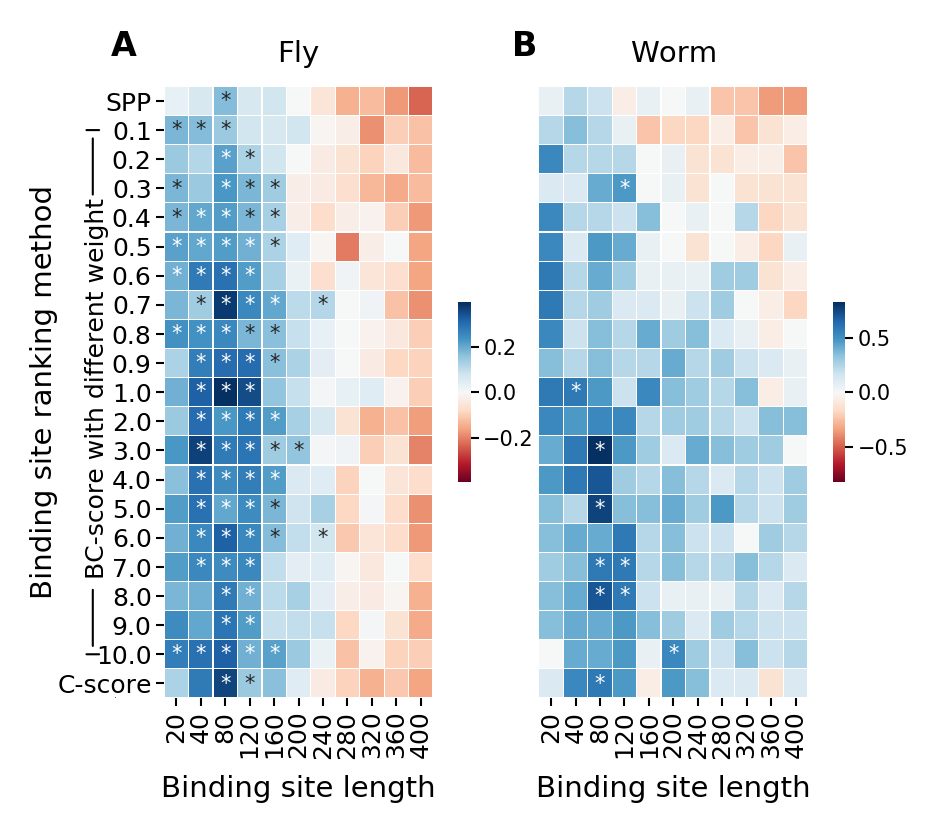

In [12]:
sns.set_context("paper")

fig = plt.figure(figsize=figsize, dpi=300)
gs = mpl.gridspec.GridSpec(3,8, width_ratios=[3, 11, 0, 0.5, 1.75, 11, 0, 0.5], wspace=0.15) 

####
ax = fig.add_subplot(gs[:, 1])
ax_cbar = fig.add_subplot(gs[1, 3])

plt_heatmap("fly_combine", ax)
ax.set_title("Fly", fontsize=title_fs)
ax.text(-0.2, 1.05, "A", transform=ax.transAxes, size=panel_number_fs, weight='bold')

ax.get_yaxis().set_ticks(np.arange(0.5,21,1))
ax.get_yaxis().set_ticklabels(["SPP","0.1", "0.2", "0.3", "0.4", "0.5", "0.6", "0.7", "0.8", "0.9", "1.0", "2.0", "3.0", "4.0", "5.0", "6.0", "7.0", "8.0", "9.0", "10.0","C-score"],  
                              fontsize=y_tick_label_fs)
ax.get_yaxis().set_tick_params(size=2, width=0.5, pad=1)
ax.set_ylabel("Binding site ranking method", fontsize=y_label_fs, labelpad=-0.2)

##### BC-score label
ax_annot = fig.add_subplot(gs[:, 0])
ax_annot.plot([1,1], [0,21], ",")
ax_annot.set_ylim([0,21])
ax_annot.set_xlim([0,2])    
ax_annot.annotate("", 
                  (0.4, 1.5),
                  (0.4, 4),
                  arrowprops=dict(arrowstyle="-", fc="k", ec="k", lw=0.5))
ax_annot.annotate("", 
                  (0.4, 17),
                  (0.4, 19.5),
                  arrowprops=dict(arrowstyle="-", fc="k", ec="k", lw=0.5))
ax_annot.annotate("", 
                  (0, 1.5),
                  (0.8, 1.5),
                  arrowprops=dict(arrowstyle="-", fc="k", ec="k", lw=0.5))
ax_annot.annotate("", 
                  (0, 19.5),
                  (0.8, 19.5),
                  arrowprops=dict(arrowstyle="-", fc="k", ec="k", lw=0.5))
ax_annot.annotate("BC-score with different weight", 
                  (0.2, 4.25),
                  (0.2, 4.25),
                  rotation=90,
                  size=6)
ax_annot.axis('off')

####
# color bar ticks
ax_cbar.get_yaxis().set_tick_params(size=2, width=0.5)
ax_cbar.tick_params(axis='y', which='major', pad=1, labelsize=legend_fs)

####
ax = fig.add_subplot(gs[:, 5])
ax_cbar = fig.add_subplot(gs[1, 7])
plt_heatmap("worm_combine", ax)
ax.set_title("Worm", fontsize=title_fs)
ax.text(-0.1, 1.05, "B", transform=ax.transAxes, size=panel_number_fs, weight='bold')

# color bar ticks
ax_cbar.get_yaxis().set_tick_params(size=2, width=0.5)
ax_cbar.tick_params(axis='y', which='major', pad=1, labelsize=legend_fs)

####
plt.savefig("./fig3_mock.pdf", dpi="figure", bbox_inches="tight")